In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv']

In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Welcome.pdf', 'IMG_0243.HEIC', 'Screenshot 2025-07-15 185158.pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM (1).pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM.pdf', 'Scanned 15 Jul 2025 at 6:59:01\u202fPM.pdf', 'DEDF6A3C-0B57-4D3B-8527-A62FCCF4C131 (1).jpeg', 'Worksheet 1.gdoc', 'english worksheet;-2', 'Copy of Worksheet - 2.gdoc', 'english worksheet 3.gdoc', ' english worksheet 3.gdoc', 'enlish worksheet-3', 'english workksheet-1', 'Copy of Worksheet 5.docx', 'Copy of Worksheet 5 (1).gdoc', 'Copy of Worksheet 5.gdoc', 'Copy of Worksheet 6.docx', 'Copy of Worksheet 6.gdoc', 'Session 7 Vocabulary (Synonyms and Antonyms) - Worksheet.gdoc', 'Copy of Session 7 worksheet.docx', 'CO1 ALM2.pdf', 'Saved from the Google app', 'Session_01_Introduction (1).pdf', 'Session_01_Introduction.pdf', 'Pikley_Pom_Baby_John_Varun_Dhawan,_Wamiqa_Vishal_Mishra,_Riya_Seepana,_Thaman_S,_Irshad_Kamil_[_YouCon.mp3', '2520030360_sec-4_video resume.mp4', 'Colab Notebooks', 'cfai', 'code tantra.pdf', 'sports fee (1

DECISION TREE CLASSIFICATION PROJECT

Dataset Loaded Successfully!

Dataset Shape:
(1143, 13)

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.997

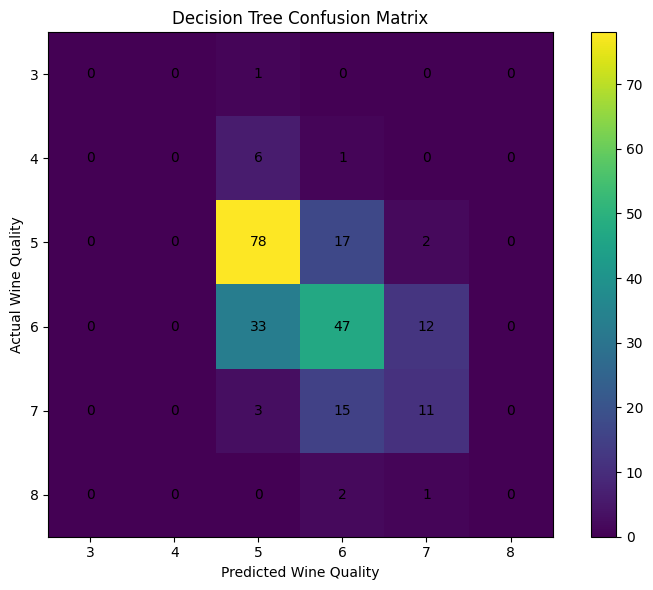


FEATURE IMPORTANCE
             Feature  Importance
             alcohol    0.364117
    volatile acidity    0.145555
total sulfur dioxide    0.141635
           sulphates    0.128837
         citric acid    0.060689
 free sulfur dioxide    0.048173
                  Id    0.043019
                  pH    0.029648
             density    0.022617
       fixed acidity    0.015709
      residual sugar    0.000000
           chlorides    0.000000


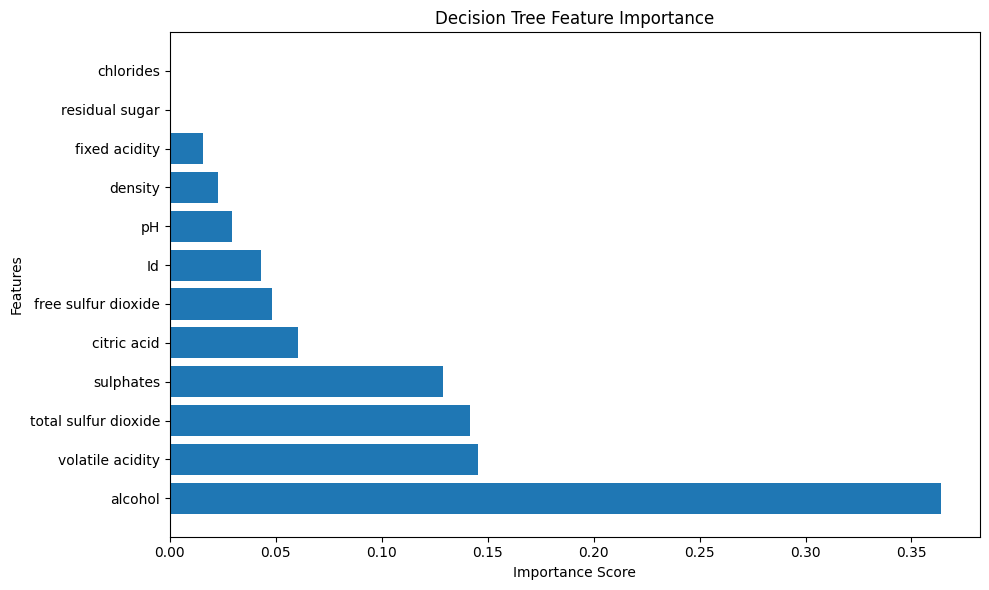

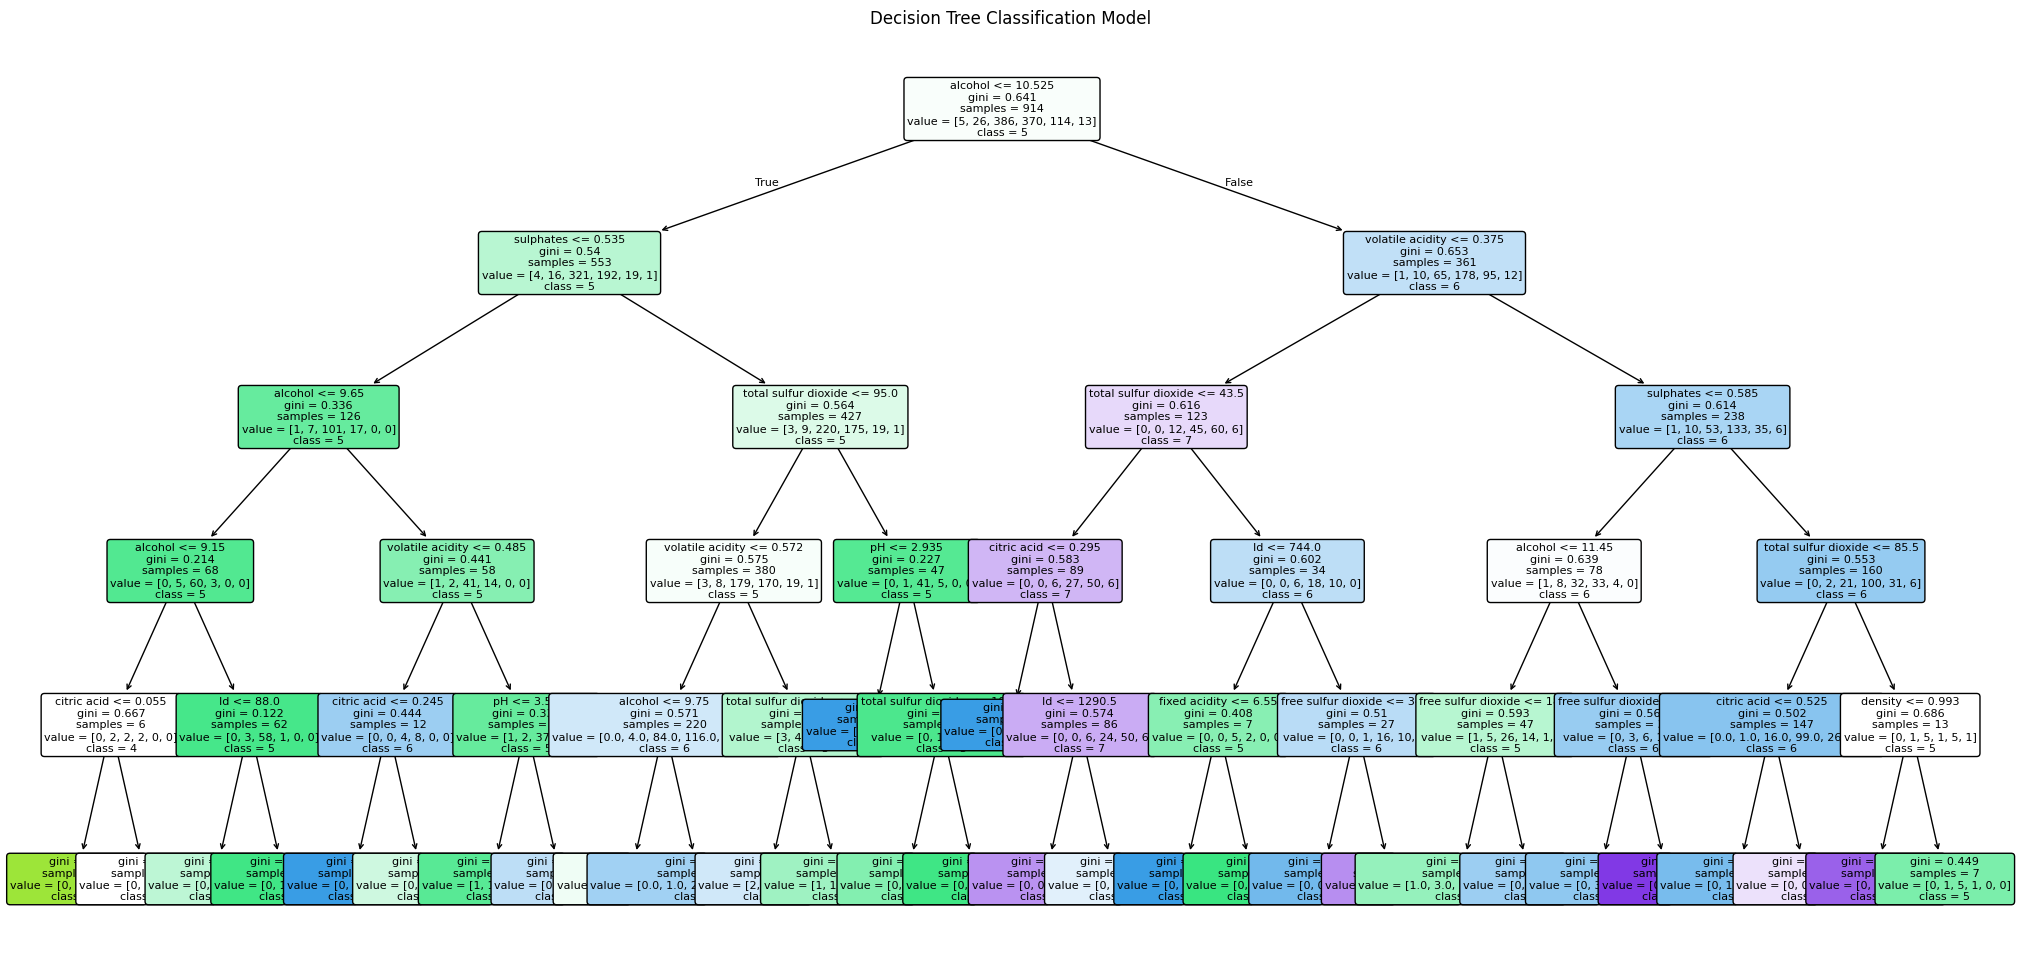


RESULTS SAVED
1. decision_tree_classification_results.csv
2. decision_tree_feature_importance.csv

FINAL CONCLUSION


The WineQT dataset was used to build a
Decision Tree Classification model.

The model predicts Wine Quality classes.

The project included:

1. Dataset Loading
2. Data Inspection
3. Missing Value Handling
4. Duplicate Removal
5. Feature and Target Separation
6. Train/Test Data Splitting
7. Decision Tree Training
8. Model Prediction
9. Accuracy Evaluation
10. Precision Evaluation
11. Recall Evaluation
12. F1 Score Evaluation
13. Confusion Matrix
14. Feature Importance Analysis
15. Decision Tree Visualization

FINAL RESULTS

Accuracy : 0.5939
Precision: 0.5569
Recall   : 0.5939
F1 Score : 0.5708




In [5]:
# ============================================================
# DECISION TREE CLASSIFICATION PROJECT
# Dataset: WineQT.csv
# Target Variable: quality
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

# Dataset path in Google Drive
DATA_PATH = "/content/drive/MyDrive/Colab/WineQT.csv"

# Target column
TARGET_COL = "quality"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DECISION TREE CLASSIFICATION PROJECT")
print("=" * 60)

print("\nDataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 5. CHECK AND REMOVE DUPLICATES
# ------------------------------------------------------------

duplicates = df.duplicated().sum()

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print("Number of Duplicate Rows:", duplicates)


if duplicates > 0:

    df = df.drop_duplicates()

    print("Duplicate rows removed!")

else:

    print("No duplicate rows found!")


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    columns=[TARGET_COL]
)

y = df[TARGET_COL]


print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)


print("\nWine Quality Classes:")

print(
    sorted(
        y.unique()
    )
)


print("\nClass Distribution:")

print(
    y.value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 7. HANDLE MISSING VALUES
# ------------------------------------------------------------

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns


imputer = SimpleImputer(
    strategy="median"
)


X[num_cols] = imputer.fit_transform(
    X[num_cols]
)


print("\nMissing values handled successfully!")


# ------------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=RANDOM_STATE

)


print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 9. CREATE DECISION TREE MODEL
# ------------------------------------------------------------

model = DecisionTreeClassifier(

    criterion="gini",

    max_depth=5,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=RANDOM_STATE

)


print("\nDecision Tree Model Created Successfully!")


# ------------------------------------------------------------
# 10. TRAIN THE MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING DECISION TREE MODEL")
print("=" * 60)


model.fit(

    X_train,

    y_train

)


print(
    "Decision Tree Model Trained Successfully!"
)


# ------------------------------------------------------------
# 11. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 12. MODEL EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(

    y_test,

    y_pred,

    average="weighted",

    zero_division=0

)


recall = recall_score(

    y_test,

    y_pred,

    average="weighted",

    zero_division=0

)


f1 = f1_score(

    y_test,

    y_pred,

    average="weighted",

    zero_division=0

)


print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)


print(
    "Accuracy :",
    round(accuracy, 4)
)


print(
    "Precision:",
    round(precision, 4)
)


print(
    "Recall   :",
    round(recall, 4)
)


print(
    "F1 Score :",
    round(f1, 4)
)


# ------------------------------------------------------------
# 13. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)


print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0

    )

)


# ------------------------------------------------------------
# 14. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,

    y_pred

)


print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)


print(cm)


# ------------------------------------------------------------
# 15. CONFUSION MATRIX VISUALIZATION
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


plt.imshow(
    cm
)


plt.colorbar()


classes = sorted(
    y.unique()
)


plt.xticks(

    range(
        len(classes)
    ),

    classes

)


plt.yticks(

    range(
        len(classes)
    ),

    classes

)


plt.xlabel(
    "Predicted Wine Quality"
)


plt.ylabel(
    "Actual Wine Quality"
)


plt.title(
    "Decision Tree Confusion Matrix"
)


# Add values inside the matrix

for i in range(
    len(cm)
):

    for j in range(
        len(cm[0])
    ):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"

        )


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 16. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance_df = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    model.feature_importances_

})


importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)


print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)


print(
    importance_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 17. FEATURE IMPORTANCE GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Features"
)


plt.title(
    "Decision Tree Feature Importance"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 18. VISUALIZE DECISION TREE
# ------------------------------------------------------------

plt.figure(
    figsize=(25, 12)
)


plot_tree(

    model,

    feature_names=X.columns,

    class_names=[
        str(c)
        for c in sorted(y.unique())
    ],

    filled=True,

    rounded=True,

    fontsize=8

)


plt.title(
    "Decision Tree Classification Model"
)


plt.show()


# ------------------------------------------------------------
# 19. SAVE RESULTS
# ------------------------------------------------------------

results_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Score": [

        accuracy,

        precision,

        recall,

        f1

    ]

})


results_df.to_csv(

    "decision_tree_classification_results.csv",

    index=False

)


importance_df.to_csv(

    "decision_tree_feature_importance.csv",

    index=False

)


print("\n" + "=" * 60)
print("RESULTS SAVED")
print("=" * 60)


print(
    "1. decision_tree_classification_results.csv"
)

print(
    "2. decision_tree_feature_importance.csv"
)


# ------------------------------------------------------------
# 20. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)


print(f"""

The WineQT dataset was used to build a
Decision Tree Classification model.

The model predicts Wine Quality classes.

The project included:

1. Dataset Loading
2. Data Inspection
3. Missing Value Handling
4. Duplicate Removal
5. Feature and Target Separation
6. Train/Test Data Splitting
7. Decision Tree Training
8. Model Prediction
9. Accuracy Evaluation
10. Precision Evaluation
11. Recall Evaluation
12. F1 Score Evaluation
13. Confusion Matrix
14. Feature Importance Analysis
15. Decision Tree Visualization

FINAL RESULTS

Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1 Score : {f1:.4f}

""")

print("=" * 60)